# 실험 과정
            ┌────────────┐       ┌───────────────┐
Image ───►  │CNN Backbone│──┐    │ Keypoint CSV  │
            └────────────┘  │    └───────┬───────┘
                            ▼            ▼
                     [Image Feature]  [CSV Feature]
                            └────┬─────┘
                                 ▼
                          🔗 Concat Layer
                                 ▼
                        🔽 MLP Classification Head
                                 ▼
                        🏷️ Binary Classification (Good/Bad)
### 라이브러리 임포트

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path
import random
from dataclasses import dataclass
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from sklearn.metrics import f1_score

In [41]:
# ---------------------------
# 1. Configuration
# ---------------------------
@dataclass
class Config:
    train_csv: Path = Path("../dataset-modification/train_pose_parsed.csv")
    valid_csv: Path = Path("../dataset-modification/valid_pose_parsed.csv")
    train_img_dir: Path = Path("../dataset-modification/train-visualized/images")
    valid_img_dir: Path = Path("../dataset-modification/valid-visualized/images")
    train_img_dir: Path = Path("../dataset-modification/train/images")
    valid_img_dir: Path = Path("../dataset-modification/valid/images")
    batch_size: int = 32
    num_epochs: int = 40
    lr: float = 1e-4
    seed: int = 42
    backbones: list = ("resnet50", "efficientnet_b0", "mobilenet_v3_large")
    backbones: list = ("resnet50")
    num_workers: int = 0  # 디버깅 목적, 실험시 CPU 코어 수로 조절 가능
    device = torch.device(
        "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
        else "cuda" if torch.cuda.is_available() else "cpu"
    )
    model_dir: Path = Path("./checkpoints")

cfg = Config()
cfg.model_dir.mkdir(parents=True, exist_ok=True)
print(f"Using device: {cfg.device}")


Using device: cuda


In [34]:
# ---------------------------
# 2. Seed for reproducibility
# ---------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)

In [35]:
# ---------------------------
# 3. Dataset Definition
# ---------------------------
class MultimodalPostureDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: Path, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.default_transform = transforms.ToTensor()
    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        image = Image.open(self.img_dir / row.filename).convert("RGB")
        if self.transform:
            image = self.transform(image)
        else:
            image = self.default_transform(image)
        width, height = row.width, row.height
        kps = []
        
        for i in range(17):
            x, y, v = row[f'kp{i}_x'], row[f'kp{i}_y'], row[f'kp{i}_v']
            kps.extend([x/width * v, y/height * v])  # v로 마스킹(가려진 점은 0,0)
        keypoints = torch.tensor(kps, dtype=torch.float32)
        label = torch.tensor(row.class_id, dtype=torch.float32)  # float32 (for BCEWithLogitsLoss)
        return image, keypoints, label

In [46]:
# ---------------------------
# 4. Backbone & Model Builder
# ---------------------------
def get_backbone(backbone_name: str):
    if backbone_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        feat_extractor = nn.Sequential(*model.features, nn.AdaptiveAvgPool2d(1))
        feat_dim = model.classifier[1].in_features
    elif backbone_name == 'mobilenet_v3_large':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        feat_extractor = nn.Sequential(*model.features, nn.AdaptiveAvgPool2d(1))
        feat_dim = model.classifier[0].in_features
    else:
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        feat_extractor = nn.Sequential(*list(model.children())[:-1])
        feat_dim = model.fc.in_features
    return feat_extractor, feat_dim

def get_mlp_head(in_features):
    return nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 1)  # 1 output (binary classification)
    )

class MultimodalModel(nn.Module):
    def __init__(self, backbone_name: str, kp_dim: int = 34):
        super().__init__()
        self.img_net, img_dim = get_backbone(backbone_name)
        self.img_fc = nn.Linear(img_dim, 256)
        # self.kp_fc = nn.Sequential(
        #     nn.Linear(kp_dim, 128), nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(128, 64)
        # )
        self.kp_fc = nn.Sequential(
            nn.Linear(kp_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 128)
        )
        # self.classifier = get_mlp_head(256 + 64)
        self.classifier = get_mlp_head(256 + 128)

    def forward(self, image: torch.Tensor, keypoints: torch.Tensor):
        x_img = self.img_net(image).view(image.size(0), -1)
        x_img = self.img_fc(x_img)
        x_kp = self.kp_fc(keypoints)
        x = torch.cat([x_img, x_kp], dim=1)
        return self.classifier(x).squeeze(1)  # (batch, )

In [47]:
# ---------------------------
# 5. Data Preparation & Transforms
# ---------------------------
def prepare_df(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    cols = ['filename', 'class_id', 'width', 'height'] + [f'kp{i}_{a}' for i in range(17) for a in ['x','y','v']]
    return df[cols].groupby('filename').first().reset_index()  # safer than .min()

train_df = prepare_df(cfg.train_csv)
valid_df = prepare_df(cfg.valid_csv)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),   # ← 반드시 고정 사이즈로 resize!
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),    # 추가!
    transforms.ToTensor(),            # 추가!
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [48]:
# ---------------------------
# 6. Training & Evaluation
# ---------------------------
def train_and_evaluate(backbone_name: str, dataloaders: dict, history_dict: dict):
    model = MultimodalModel(backbone_name).to(cfg.device)
    crit = nn.BCEWithLogitsLoss()
    optim_ = optim.Adam(model.parameters(), lr=cfg.lr)
    best_val_f1 = 0.0

    # 기록을 위한 리스트
    epoch_train_loss, epoch_valid_loss = [], []
    epoch_train_f1, epoch_valid_f1 = [], []

    for epoch in range(1, cfg.num_epochs+1):
        for phase in ['train', 'valid']:
            is_train = phase == 'train'
            model.train() if is_train else model.eval()
            running_loss, preds, labels = 0.0, [], []

            for images, kps, labs in tqdm(dataloaders[phase], desc=f"{backbone_name} {phase} Ep{epoch}"):
                imgs, kpts, labs = images.to(cfg.device), kps.to(cfg.device), labs.to(cfg.device)
                optim_.zero_grad()
                with torch.set_grad_enabled(is_train):
                    outs = model(imgs, kpts)
                    loss = crit(outs, labs)
                    if is_train:
                        loss.backward()
                        optim_.step()
                running_loss += loss.item() * imgs.size(0)
                preds.extend((outs.sigmoid() > 0.5).int().cpu().numpy())
                labels.extend(labs.int().cpu().numpy())

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_f1 = f1_score(labels, preds, average='macro')
            print(f"{backbone_name} {phase} Ep{epoch}: Loss={epoch_loss:.4f}, F1={epoch_f1:.4f}")

            if phase == 'train':
                epoch_train_loss.append(epoch_loss)
                epoch_train_f1.append(epoch_f1)
            else:
                epoch_valid_loss.append(epoch_loss)
                epoch_valid_f1.append(epoch_f1)

                if epoch_f1 > best_val_f1:
                    best_val_f1 = epoch_f1
                    ckpt = cfg.model_dir / f"{backbone_name}_best.pth"
                    torch.save(model.state_dict(), ckpt)
                    print(f"[Saved] {backbone_name} best model at {ckpt}")

    # 기록 저장
    history_dict[backbone_name] = {
        'train_loss': epoch_train_loss,
        'valid_loss': epoch_valid_loss,
        'train_f1': epoch_train_f1,
        'valid_f1': epoch_valid_f1
    }


In [ ]:
# ---------------------------
# 7. Main
# ---------------------------
if __name__ == '__main__':
    datasets = {
        'train': MultimodalPostureDataset(train_df, cfg.train_img_dir, train_transform),
        'valid': MultimodalPostureDataset(valid_df, cfg.valid_img_dir, val_transform)
    }
    loaders = {
        phase: DataLoader(
            datasets[phase], batch_size=cfg.batch_size,
            shuffle=(phase == 'train'), num_workers=cfg.num_workers
        ) for phase in ['train', 'valid']
    }

    history = dict()   # backbone별 로그 기록용

    for bb in cfg.backbones:
        print(f"\n=== Training backbone: {bb} ===")
        train_and_evaluate(bb, loaders, history)

    # ---- 학습 끝난 뒤 시각화 ----
    import matplotlib.pyplot as plt

    epochs = range(1, cfg.num_epochs+1)

    plt.figure(figsize=(16, 6))

    # 1. Loss plot
    plt.subplot(1,2,1)
    for bb in cfg.backbones:
        plt.plot(epochs, history[bb]['train_loss'], label=f'{bb} train')
        plt.plot(epochs, history[bb]['valid_loss'], '--', label=f'{bb} valid')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Epoch-wise Loss (Train/Valid)')
    plt.legend()

    # 2. F1 plot
    plt.subplot(1,2,2)
    for bb in cfg.backbones:
        plt.plot(epochs, history[bb]['train_f1'], label=f'{bb} train')
        plt.plot(epochs, history[bb]['valid_f1'], '--', label=f'{bb} valid')
    plt.xlabel('Epoch')
    plt.ylabel('Macro F1')
    plt.title('Epoch-wise Macro F1 (Train/Valid)')
    plt.legend()

    plt.tight_layout()
    plt.show()



=== Training backbone: r ===


r train Ep1: 100%|██████████| 81/81 [00:34<00:00,  2.35it/s]


r train Ep1: Loss=0.5682, F1=0.6932


r valid Ep1: 100%|██████████| 22/22 [00:04<00:00,  4.70it/s]


r valid Ep1: Loss=0.3993, F1=0.8065
[Saved] r best model at checkpoints\r_best.pth


...

r valid Ep18: 100%|██████████| 22/22 [00:05<00:00,  4.35it/s]


r valid Ep18: Loss=0.5747, F1=0.8536


r train Ep19: 100%|██████████| 81/81 [00:37<00:00,  2.14it/s]


r train Ep19: Loss=0.1604, F1=0.9259


r valid Ep19:  82%|████████▏ | 18/22 [00:04<00:01,  3.94it/s]

In [22]:
import pprint
pprint.pprint(history)

{'efficientnet_b0': {'train_f1': [0.6221513598728293,
                                  0.8424771365795947,
                                  0.9095516658036646,
                                  0.9456962605670072,
                                  0.9432454302943183,
                                  0.9537538947860791,
                                  0.9611869485287206,
                                  0.9595429180512884,
                                  0.9607105456475453,
                                  0.971318079278118,
                                  0.9651836389485982,
                                  0.9656399449637699,
                                  0.9684117472061097,
                                  0.9652299747236457,
                                  0.9688942549917616,
                                  0.973262450086642,
                                  0.9717450242967456,
                                  0.9761500794454403,
                              

In [24]:
import pandas as pd

backbones = ['resnet50', 'efficientnet_b0','mobilenet_v3_large']  # 필요한 backbone만

epochs = range(1, len(history[backbones[0]]['train_loss']) + 1)

records = []

for i, epoch in enumerate(epochs):
    row = {'epoch': epoch}
    for bb in backbones:
        row[f'{bb}_train_loss'] = history[bb]['train_loss'][i]
        row[f'{bb}_valid_loss'] = history[bb]['valid_loss'][i]
        row[f'{bb}_train_f1']   = history[bb]['train_f1'][i]
        row[f'{bb}_valid_f1']   = history[bb]['valid_f1'][i]
    records.append(row)

df = pd.DataFrame(records)
print(df)


    epoch  resnet50_train_loss  resnet50_valid_loss  resnet50_train_f1  \
0       1             0.507065             0.384876           0.757850   
1       2             0.254027             0.355050           0.899993   
2       3             0.152898             0.457974           0.940538   
3       4             0.124993             0.462493           0.947610   
4       5             0.104542             0.428893           0.956732   
5       6             0.093222             0.591886           0.959623   
6       7             0.071270             0.638615           0.969702   
7       8             0.081620             0.606772           0.964398   
8       9             0.088572             0.661067           0.959543   
9      10             0.075157             0.684628           0.966836   
10     11             0.075449             0.553938           0.966735   
11     12             0.058141             0.543036           0.973334   
12     13             0.049920        

In [25]:
df.to_csv('multimodal_no_aug_history.csv', index=False)


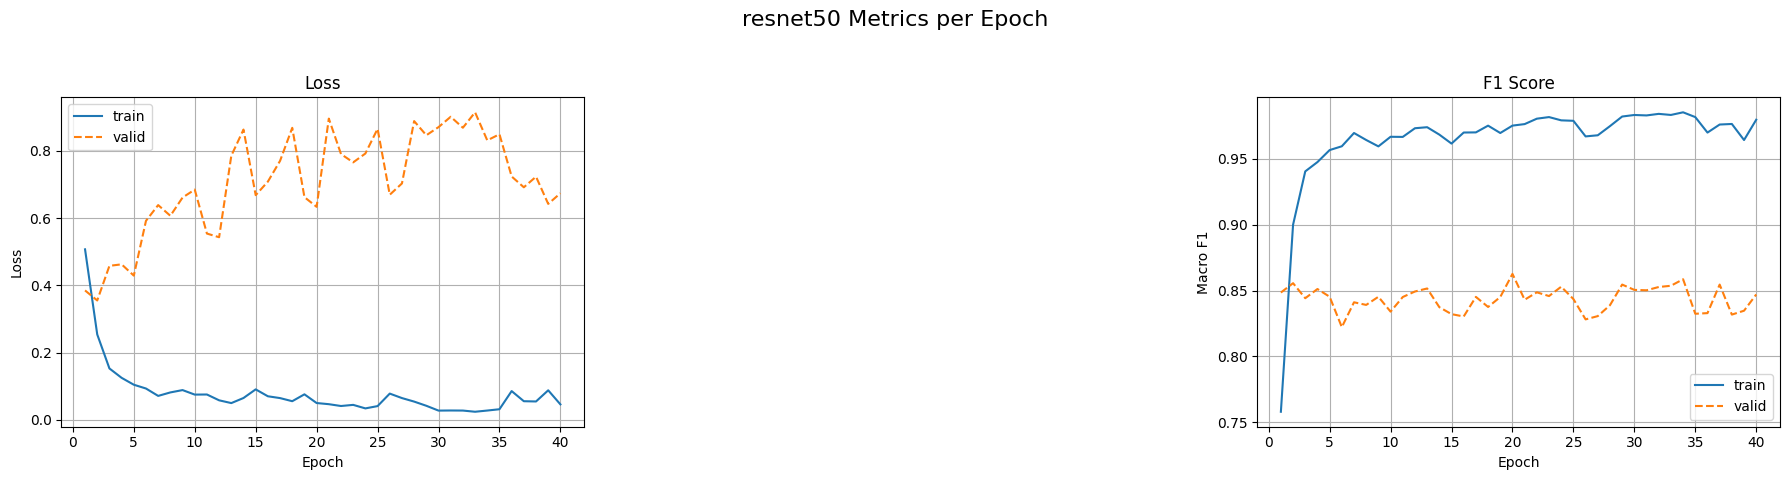

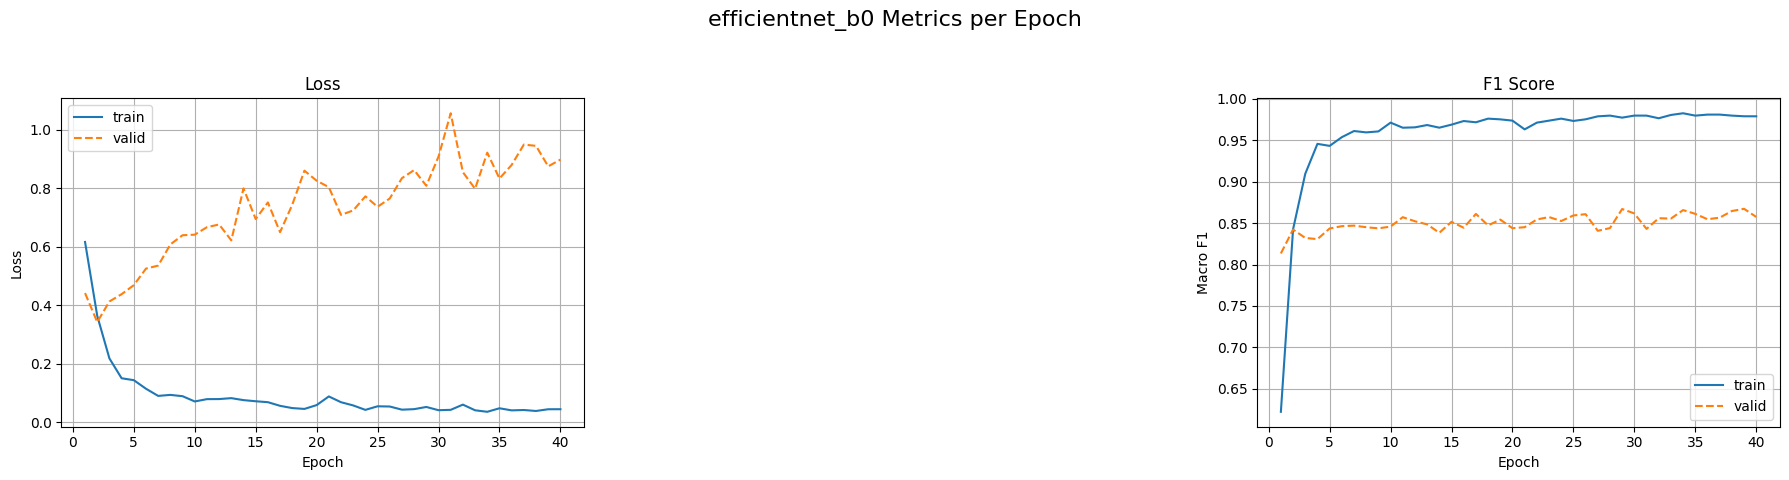

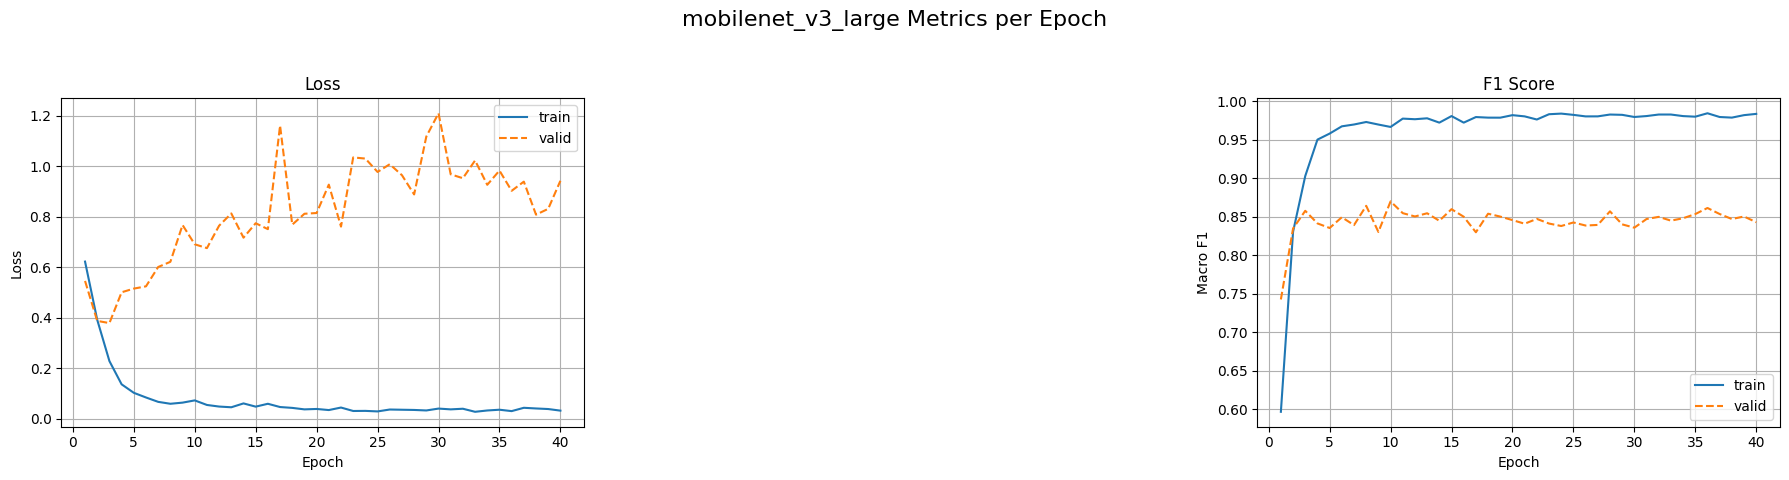

In [32]:
import matplotlib.pyplot as plt

backbones = ['resnet50', 'efficientnet_b0','mobilenet_v3_large']  # 원하는 backbone만

for bb in backbones:
    epochs = range(1, len(history[bb]['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{bb} Metrics per Epoch', fontsize=16)

    # 1. Loss
    axes[0].plot(epochs, history[bb]['train_loss'], label='train')
    axes[0].plot(epochs, history[bb]['valid_loss'], '--', label='valid')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # 2. Accuracy (있는 경우만)
    if 'train_acc' in history[bb]:
        axes[1].plot(epochs, history[bb]['train_acc'], label='train')
        axes[1].plot(epochs, history[bb]['valid_acc'], '--', label='valid')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Accuracy')
        axes[1].legend()
        axes[1].grid(True)
    else:
        axes[1].axis('off')  # 비워두기

    # 3. F1 Score
    axes[2].plot(epochs, history[bb]['train_f1'], label='train')
    axes[2].plot(epochs, history[bb]['valid_f1'], '--', label='valid')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Macro F1')
    axes[2].set_title('F1 Score')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [ ]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from sklearn.metrics import f1_score
import numpy as np
import torch
import os
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn as nn
import timm  # pip install timm
import torch.optim as optim
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
import pandas as pd
from PIL import Image
import torch.utils
from torchvision import transforms
from sklearn.metrics import accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path
import random
from tqdm import tqdm
from torchvision import models

# ---------------------------
# 1. Configuration
# ---------------------------
@dataclass
class Config:
    train_csv: Path = Path("../dataset-modification/train_pose_parsed.csv")
    valid_csv: Path = Path("../dataset-modification/valid_pose_parsed.csv")
    train_img_dir: Path = Path("../dataset-modification/train-visualized/images")
    valid_img_dir: Path = Path("../dataset-modification/valid-visualized/images")
    batch_size: int = 32
    num_epochs: int = 40
    lr: float = 1e-4
    seed: int = 42
    backbones: list = ("resnet50", "efficientnet_b0", "mobilenet_v3_large")
    num_workers: int = 0  # disable multiprocessing workers to avoid pickle errors in DataLoader
    device = torch.device("mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built()
                        else "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    model_dir: Path = Path("./checkpoints")

cfg = Config()
cfg.model_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------
# 2. Seed for reproducibility
# ---------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

# ---------------------------
# 3. Dataset Definition
# ---------------------------
class MultimodalPostureDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: Path, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        image = Image.open(self.img_dir / row.filename).convert("RGB")
        if self.transform:
            image = self.transform(image)

        width, height = row.width, row.height
        kps = []
        for i in range(17):
            x, y, v = row[f'kp{i}_x'], row[f'kp{i}_y'], row[f'kp{i}_v']
            kps.extend([x/width * v, y/height * v])
        keypoints = torch.tensor(kps, dtype=torch.float32)
        label = torch.tensor(row.class_id, dtype=torch.long)
        return image, keypoints, label


def get_mlp_head(in_features):
    return nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 1)   # 1 output (for binary classification)
    )


# ---------------------------
# 4. Backbone & Model Builder
# ---------------------------
def get_backbone(backbone_name: str):
    if backbone_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        feat_extractor = nn.Sequential(*model.features, nn.AdaptiveAvgPool2d(1))
        feat_dim = model.classifier[1].in_features
    elif backbone_name == 'mobilenet_v3_large':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        feat_extractor = nn.Sequential(*model.features, nn.AdaptiveAvgPool2d(1))
        feat_dim = model.classifier[0].in_features
    else:
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        feat_extractor = nn.Sequential(*list(model.children())[:-1])
        feat_dim = model.fc.in_features
    return feat_extractor, feat_dim

class MultimodalModel(nn.Module):
    def __init__(self, backbone_name: str, num_classes: int = 2, kp_dim: int = 34):
        super().__init__()
        self.img_net, img_dim = get_backbone(backbone_name)
        self.img_fc = nn.Linear(img_dim, 256)
        self.kp_fc = nn.Sequential(
            nn.Linear(kp_dim, 128), nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(128, 64)
        )
        # self.classifier = nn.Sequential(
        #     nn.Linear(256 + 64, 128), nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(128, num_classes)
        # )
        self.classifier = get_mlp_head(256 + 64)

    def forward(self, image: torch.Tensor, keypoints: torch.Tensor):
        x_img = self.img_net(image).view(image.size(0), -1)
        x_img = self.img_fc(x_img)
        x_kp = self.kp_fc(keypoints)
        return self.classifier(torch.cat([x_img, x_kp], dim=1))

# ---------------------------
# 5. Data Preparation & Transforms
# ---------------------------
def prepare_df(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    cols = ['filename','class_id','width','height'] + [f'kp{i}_{a}' for i in range(17) for a in ['x','y','v']]
    return df[cols].groupby('filename').min().reset_index()

train_df = prepare_df(cfg.train_csv)
valid_df = prepare_df(cfg.valid_csv)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ---------------------------
# 6. Training & Evaluation
# ---------------------------
def train_and_evaluate(backbone_name: str, dataloaders: dict):
    model = MultimodalModel(backbone_name).to(cfg.device)
    crit = nn.CrossEntropyLoss()
    optim_ = optim.Adam(model.parameters(), lr=cfg.lr)
    best_val_f1 = 0.0

    for epoch in range(1, cfg.num_epochs+1):
        for phase in ['train','valid']:
            is_train = phase=='train'
            model.train() if is_train else model.eval()
            running_loss, preds, labels = 0.0, [], []

            for images, kps, lbls in tqdm(dataloaders[phase], desc=f"{backbone_name} {phase} Ep{epoch}"):
                imgs, kpts, labs = images.to(cfg.device), kps.to(cfg.device), lbls.to(cfg.device)
                optim_.zero_grad()
                with torch.set_grad_enabled(is_train):
                    outs = model(imgs, kpts)
                    loss = crit(outs, labs)
                    if is_train:
                        loss.backward(); optim_.step()
                running_loss += loss.item()*imgs.size(0)
                preds.extend(outs.argmax(1).cpu().numpy())
                labels.extend(labs.cpu().numpy())

            epoch_loss = running_loss/len(dataloaders[phase].dataset)
            epoch_f1 = f1_score(labels, preds, average='macro')
            print(f"{backbone_name} {phase} Ep{epoch}: Loss={epoch_loss:.4f}, F1={epoch_f1:.4f}")

            if phase=='valid' and epoch_f1>best_val_f1:
                best_val_f1 = epoch_f1
                ckpt = cfg.model_dir / f"{backbone_name}_best.pth"
                torch.save(model.state_dict(), ckpt)
                print(f"[Saved] {backbone_name} best model at {ckpt}")

# ---------------------------
# 7. Main
# ---------------------------
if __name__ == '__main__':
    datasets = {
        'train': MultimodalPostureDataset(train_df, cfg.train_img_dir, train_transform),
        'valid': MultimodalPostureDataset(valid_df, cfg.valid_img_dir, val_transform)
    }
    loaders = {
        phase: DataLoader(
            datasets[phase], batch_size=cfg.batch_size,
            shuffle=(phase=='train'), num_workers=cfg.num_workers
        ) for phase in ['train','valid']
    }

    for bb in cfg.backbones:
        print(f"\n=== Training backbone: {bb} ===")
        train_and_evaluate(bb, loaders)


/opt/miniconda3/envs/Pose-Detection/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps

=== Training backbone: resnet50 ===


resnet50 train Ep1: 100%|██████████| 81/81 [01:07<00:00,  1.20it/s]


resnet50 train Ep1: Loss=0.5223, F1=0.6908


resnet50 valid Ep1: 100%|██████████| 22/22 [00:06<00:00,  3.21it/s]


...

mobilenet_v3_large valid Ep9: Loss=0.3916, F1=0.8673


mobilenet_v3_large train Ep10: 100%|██████████| 81/81 [00:29<00:00,  2.75it/s]


mobilenet_v3_large train Ep10: Loss=0.1487, F1=0.9374


mobilenet_v3_large valid Ep10: 100%|██████████| 22/22 [00:03<00:00,  6.11it/s]

mobilenet_v3_large valid Ep10: Loss=0.3740, F1=0.8715
